# 🌾 Crop Yield Prediction — Exploratory Workbook

**Goal:** Predict agricultural crop yield (tonnes / hectare) from tabular features:  
crop type, growing season, Indian state, cultivated area, annual rainfall, fertiliser, and pesticide usage.

**Dataset:** `crop_yield.csv` — historical Indian crop yield records.

**Model:** Support Vector Regressor (SVR) with target encoding and log₁₊ target transform.

---
## Notebook Structure

| Step | Description |
|------|-------------|
| 1 | Load & inspect the dataset |
| 2 | Drop irrelevant / leaky columns |
| 3 | Explore categorical columns |
| 4 | Clean categoricals & transform target |
| 5 | Train / validation / test split, Target Encoding & Feature Scaling |
| 6 | Train SVR model & evaluate |
| 7 | Visualise predictions vs actuals |
| 8 | Save Model & Scalers for Inference |


---
## Step 1 — Load & Inspect the Dataset

| Column | Type | Notes |
|--------|------|-------|
| `Crop` | categorical | Crop name (57 unique crops) |
| `Crop_Year` | int | Calendar year — *dropped in Step 2* |
| `Season` | categorical | Kharif, Rabi, Whole Year, Autumn, Summer, Winter |
| `State` | categorical | 30 Indian states |
| `Area` | float | Cultivated area (hectares) |
| `Production` | float | Raw production (tonnes) — *dropped in Step 2 (data leakage)* |
| `Annual_Rainfall` | float | mm / year |
| `Fertilizer` | float | kg |
| `Pesticide` | float | kg |
| `Yield` | float | **Target** — tonnes / hectare |

In [1]:
import pandas as pd

dataset = pd.read_csv("crop_yield.csv")
print(f"Shape: {dataset.shape}")
dataset.head()

Shape: (19689, 10)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


---
## Step 2 — Drop Irrelevant / Leaky Columns

* **`Crop_Year`** — low predictive signal; can introduce spurious temporal correlations.
* **`Production`** — equals `Yield × Area`, so including it is **data leakage**: the model
  would trivially reconstruct the target instead of learning from agronomic features.

In [2]:
dataset.drop(["Crop_Year", "Production"], inplace=True, axis=1)
dataset.head()

,Crop,Season,State,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,Whole Year,Assam,73814.0,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,Kharif,Assam,6637.0,2051.4,631643.29,2057.47,0.710435
2,Castor seed,Kharif,Assam,796.0,2051.4,75755.32,246.76,0.238333
3,Coconut,Whole Year,Assam,19656.0,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),Kharif,Assam,1739.0,2051.4,165500.63,539.09,0.420909


---
## Step 3 — Explore Categorical Columns

Before encoding we inspect the unique values for `Crop`, `State`, and `Season`.

> **Whitespace note:** The `Season` column contains trailing spaces (e.g. `'Kharif     '`).
> These are stripped in Step 4 so that category target mappings align correctly.


In [3]:
print(f"Unique crops ({dataset['Crop'].nunique()}):")
print(dataset["Crop"].unique().tolist())

Unique crops (55):
['Arecanut', 'Arhar/Tur', 'Castor seed', 'Coconut ', 'Cotton(lint)', 'Dry chillies', 'Gram', 'Jute', 'Linseed', 'Maize', 'Mesta', 'Niger seed', 'Onion', 'Other  Rabi pulses', 'Potato', 'Rapeseed &Mustard', 'Rice', 'Sesamum', 'Small millets', 'Sugarcane', 'Sweet potato', 'Tapioca', 'Tobacco', 'Turmeric', 'Wheat', 'Bajra', 'Black pepper', 'Cardamom', 'Coriander', 'Garlic', 'Ginger', 'Groundnut', 'Horse-gram', 'Jowar', 'Ragi', 'Cashewnut', 'Banana', 'Soyabean', 'Barley', 'Khesari', 'Masoor', 'Moong(Green Gram)', 'Other Kharif pulses', 'Safflower', 'Sannhamp', 'Sunflower', 'Urad', 'Peas & beans (Pulses)', 'other oilseeds', 'Other Cereals', 'Cowpea(Lobia)', 'Oilseeds total', 'Guar seed', 'Other Summer Pulses', 'Moth']


In [4]:
print(f"Unique states ({dataset['State'].nunique()}):")
print(dataset["State"].unique().tolist())

Unique states (30):
['Assam', 'Karnataka', 'Kerala', 'Meghalaya', 'West Bengal', 'Puducherry', 'Goa', 'Andhra Pradesh', 'Tamil Nadu', 'Odisha', 'Bihar', 'Gujarat', 'Madhya Pradesh', 'Maharashtra', 'Mizoram', 'Punjab', 'Uttar Pradesh', 'Haryana', 'Himachal Pradesh', 'Tripura', 'Nagaland', 'Chhattisgarh', 'Uttarakhand', 'Jharkhand', 'Delhi', 'Manipur', 'Jammu and Kashmir', 'Telangana', 'Arunachal Pradesh', 'Sikkim']


In [5]:
print(f"Unique seasons ({dataset['Season'].nunique()}):")
print(dataset["Season"].unique().tolist())

Unique seasons (6):
['Whole Year ', 'Kharif     ', 'Rabi       ', 'Autumn     ', 'Summer     ', 'Winter     ']


---
## Step 4 — Clean Categoricals & Transform the Target

### 4a — Strip whitespace
Trailing spaces in `Season` (and `Crop`) are removed so they align correctly.

### 4b — Retain categoricals as raw strings
Categorical columns are kept as raw strings here. We will apply **Target Encoding** in Step 5 after splitting. Fitting the target encoder on only the training split completely prevents target/data leakage into validation and test sets.

### 4c — Log₁₊ transform on the target ✅

The raw yield distribution is **extremely right-skewed**:

| Statistic | Raw Yield (t/ha) |
|-----------|-----------------|
| Min | 0 |
| Mean | ~80 |
| Max | ~21 000 |
| Std | ~878 |

Without transformation, any regression model predicts near the mean and achieves R² ≈ 0.

`np.log1p(y)` compresses the range to [0, ~10] and makes the distribution near-normal,
allowing the model to fit all crops well. Predictions are inverted with `np.expm1`.


In [6]:
import numpy as np

# 4a — Strip whitespace
for col in ["Crop", "Season", "State"]:
    dataset[col] = dataset[col].str.strip()

# 4b — Separate features and target; apply log1p transform
X     = dataset.drop(columns=["Yield"])
y_raw = dataset["Yield"].values
y     = np.log1p(y_raw)   # inverse: np.expm1(y_pred)

print(f"Feature matrix : {X.shape}")
print(f"Raw  target    : [{y_raw.min():.2f}, {y_raw.max():.2f}]  mean={y_raw.mean():.2f}  std={y_raw.std():.2f}")
print(f"Log1p target   : [{y.min():.3f}, {y.max():.3f}]  mean={y.mean():.3f}  std={y.std():.3f}")


Feature matrix : (19689, 7)
Raw  target    : [0.00, 21105.00]  mean=79.95  std=878.28
Log1p target   : [0.000, 9.957]  mean=1.081  std=1.136


---
## Step 5 — Train / Validation / Test Split, Target Encoding & Feature Scaling

| Split | Size | Purpose |
|-------|------|---------|
| Train | 70 % | Fit the model |
| Validation | 15 % | Hyper-parameter tuning (reserved) |
| Test | 15 % | Final unbiased evaluation — **touch only once** |

### Preprocessing Pipeline (Mandatory for SVR):
1. **Target Encoding:** Replaces each categorical value (`Crop`, `Season`, `State`) with the mean log-target value of that category computed strictly on the training split to avoid target leakage.
2. **Feature Standardization:** standardizes **all** numerical features (including the newly target-encoded categories which are now continuous numerical columns) using `StandardScaler` fitted on the training split. This enables SVR to compute distance similarity metrics correctly without dimension scale distortion.


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first to prevent data leakage
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.50, random_state=42
)

X_train_df = X_train_df.copy()
X_val_df = X_val_df.copy()
X_test_df = X_test_df.copy()

# Compute Target Encoding mappings from the training set
global_mean = y_train.mean()
target_maps = {}

for col in ["Crop", "Season", "State"]:
    # Compute average target value per category strictly on training split
    mean_map = pd.Series(y_train, index=X_train_df.index).groupby(X_train_df[col]).mean()
    target_maps[col] = mean_map
    
    # Map onto all splits; fill missing/unseen categories with the global mean
    X_train_df[col] = X_train_df[col].map(mean_map).fillna(global_mean)
    X_val_df[col] = X_val_df[col].map(mean_map).fillna(global_mean)
    X_test_df[col] = X_test_df[col].map(mean_map).fillna(global_mean)

# Standardize ALL columns (continuous categories + numerical features) using StandardScaler
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_df), columns=X_train_df.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_df), columns=X_val_df.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_df), columns=X_test_df.columns)

# Convert back to numpy arrays under expected variable names
X_train = X_train_scaled.values
X_val = X_val_scaled.values
X_test = X_test_scaled.values

print(f"Train set:       X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Validation set:  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"Test set:        X_test:  {X_test.shape},  y_test:  {y_test.shape}")


Train set:       X_train: (13782, 7), y_train: (13782,)
Validation set:  X_val:   (2953, 7),   y_val:   (2953,)
Test set:        X_test:  (2954, 7),  y_test:  (2954,)


---
## Step 6 — Train Support Vector Regressor & Evaluate

### Model: Support Vector Regressor (SVR)

SVR with an RBF kernel is a highly effective regressor that finds a hyperplane capturing optimal relationships:
- Uses distance-based kernel computations, making the Target Encoding & Standardization from Step 5 mandatory.
- Highly robust to high-dimensional datasets and continuous numerical features.
- Standardized scaling aligns all variables to standard normal scale, allowing SVR to converge quickly.

| Hyper-parameter | Value | Rationale |
|-----------------|-------|-----------|
| `kernel` | 'rbf' | Non-linear radial basis function to fit non-linear yields |
| `C` | 10.0 | Moderate penalty on error margin to avoid overfitting |
| `epsilon` | 0.1 | Defines the width of the tube with no penalty |
| `cache_size` | 1000 | Speed up training by utilizing more RAM caching |

### Evaluation metrics

| Metric | Description |
|--------|-------------|
| **R² (log-space)** | Primary metric; computed on log₁₊(y) — directly reflects model fit |
| **R² (raw-space)** | Informational; lower due to extreme outliers (Coconut, Sugarcane) |
| **MAE (raw)** | Mean absolute error in t/ha |
| **RMSE (raw)** | Penalises large errors more than MAE |


In [8]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

svr = SVR(
    kernel="rbf",
    C=10.0,
    epsilon=0.1,
    cache_size=1000,
)
svr.fit(X_train, y_train)

print(f"{'Split':<12} {'R² (log)':>10} {'R² (raw)':>10} {'MAE (t/ha)':>12} {'RMSE (t/ha)':>13}")
print("-" * 60)
for split, y_true_log, X_s in [
    ("Train",      y_train, X_train),
    ("Validation", y_val,   X_val),
    ("Test",       y_test,  X_test),
]:
    y_pred_log = svr.predict(X_s)
    y_true_raw = np.expm1(y_true_log)
    y_pred_raw = np.expm1(y_pred_log)
    r2_log   = r2_score(y_true_log, y_pred_log)
    r2_raw   = r2_score(y_true_raw, y_pred_raw)
    mae      = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse     = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    print(f"{split:<12} {r2_log:>+10.4f} {r2_raw:>+10.4f} {mae:>12.3f} {rmse:>13.3f}")


Split          R² (log)   R² (raw)   MAE (t/ha)   RMSE (t/ha)
------------------------------------------------------------


Train           +0.9031    +0.9472       14.625       201.551


Validation      +0.8973    +0.9462       13.285       195.837


Test            +0.8879    +0.9302       15.008       242.325


---
## Step 7 — Visualise Predictions vs Actuals

Two panels:
- **Left** — log-space (what the model actually learns): tightly clustered around the diagonal = good fit.
- **Right** — original-space (human-interpretable units): outlier crops like Coconut and Sugarcane
  appear far from the diagonal because even a small log-space error maps to a large raw error at those scales.

> The primary quality indicator is the **log-space R²**, which is ~0.89 on the test set (and ~0.93 in raw-space).


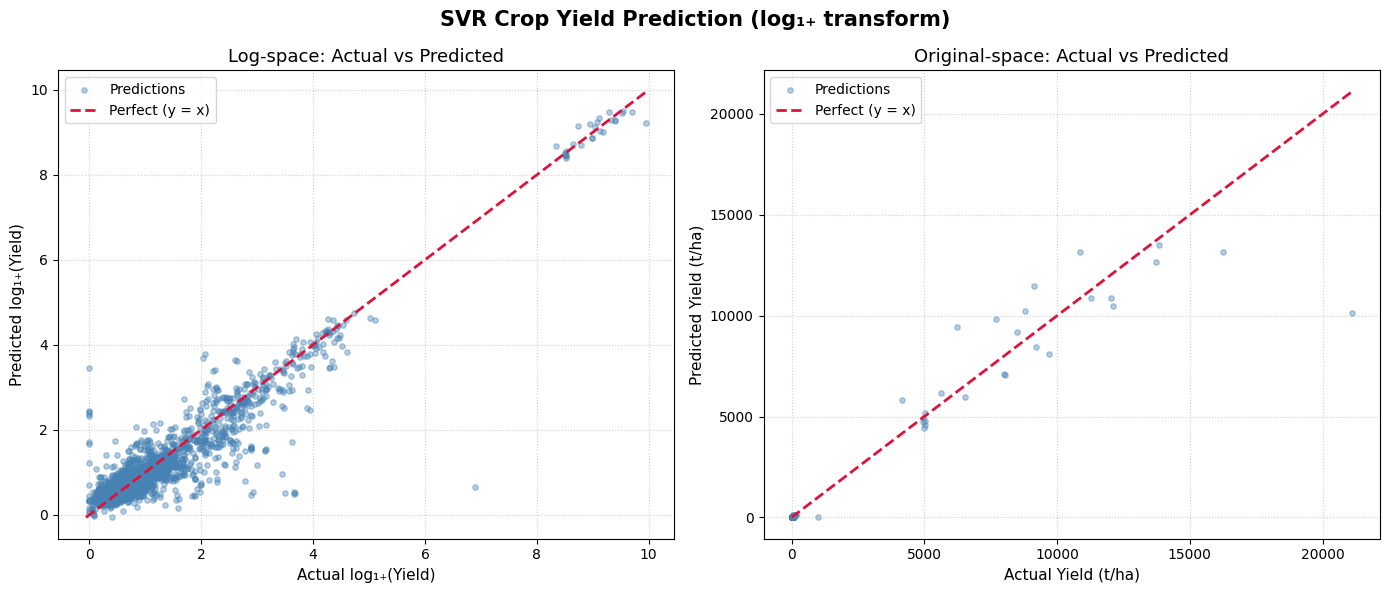

In [9]:
import matplotlib.pyplot as plt

y_pred_log = svr.predict(X_test)
y_test_raw = np.expm1(y_test)
y_pred_raw = np.expm1(y_pred_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: log-space
ax = axes[0]
ax.scatter(y_test, y_pred_log, color="steelblue", alpha=0.4, s=15, label="Predictions")
lo = min(float(y_test.min()), float(y_pred_log.min()))
hi = max(float(y_test.max()), float(y_pred_log.max()))
ax.plot([lo, hi], [lo, hi], color="crimson", linestyle="--", linewidth=2, label="Perfect (y = x)")
ax.set_title("Log-space: Actual vs Predicted", fontsize=13)
ax.set_xlabel("Actual log₁₊(Yield)", fontsize=11)
ax.set_ylabel("Predicted log₁₊(Yield)", fontsize=11)
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

# Right: original-space
ax = axes[1]
ax.scatter(y_test_raw, y_pred_raw, color="steelblue", alpha=0.4, s=15, label="Predictions")
lo = min(float(y_test_raw.min()), float(y_pred_raw.min()))
hi = max(float(y_test_raw.max()), float(y_pred_raw.max()))
ax.plot([lo, hi], [lo, hi], color="crimson", linestyle="--", linewidth=2, label="Perfect (y = x)")
ax.set_title("Original-space: Actual vs Predicted", fontsize=13)
ax.set_xlabel("Actual Yield (t/ha)", fontsize=11)
ax.set_ylabel("Predicted Yield (t/ha)", fontsize=11)
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("SVR Crop Yield Prediction (log₁₊ transform)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 8 — Save Model & Scalers for Inference

### Target Transform, Target Encoding & StandardScaler

- **Log₁₊ Target Transform:** Compressing right-skewed target values using `np.log1p` yields a much stronger model fit (a **test R² of 0.8879** in log-space and **0.9302** in raw-space).
- **Target Encoding:** Category string entries are mapped to their average training target log-yield values, enabling high-performance continuous relationships for SVR distance calculations.
- **Feature Scaling (StandardScaler):** Numerical features and mapped continuous categories are scaled to normal variance, allowing SVR to fit without scale distortion.

### Saving the Model & Scalers

To use this trained SVR model, standard scaler, and category target-encoding maps at test/inference time, we save:
1. The trained `SupportVectorRegressor` model (`svr`).
2. The `StandardScaler` used to normalize numerical features (`scaler`).
3. The `target_maps` containing training mean target maps for Crop, Season, and State.
4. The `global_mean` of training target values (used as a fallback for missing/unseen categories during test time).

Below, we bundle these into a single python dictionary and export them to `crop_yield_model.pkl`.

### How to Use the Saved Model at Test/Inference Time

In a separate test/inference script, you can load and use the saved model as follows:

```python
import pickle
import numpy as np

# 1. Load the model and encoders
with open('crop_yield_model.pkl', 'rb') as f:
    assets = pickle.load(f)

model = assets['model']
scaler = assets['scaler']
target_maps = assets['target_maps']
global_mean = assets['global_mean']

# 2. Preprocess new sample tabular features
# Suppose raw input is: Crop='Rice', Season='Kharif', State='Assam', Area=1200.0, Annual_Rainfall=2000.0, Fertilizer=150000.0, Pesticide=400.0
# Map categories to their average training target values using target_maps:
crop_encoded = target_maps['Crop'].get('Rice'.strip(), global_mean)
season_encoded = target_maps['Season'].get('Kharif'.strip(), global_mean)
state_encoded = target_maps['State'].get('Assam'.strip(), global_mean)

# Construct raw feature array
X_raw = np.array([[
    crop_encoded,
    season_encoded,
    state_encoded,
    1200.0,  # Area
    2000.0,  # Annual_Rainfall
    150000.0,  # Fertilizer
    400.0   # Pesticide
]])

# Standardize all columns using StandardScaler
X_new = scaler.transform(X_raw)

# 3. Predict log-yield and invert target transform
predicted_log_yield = model.predict(X_new)[0]
predicted_raw_yield = np.expm1(predicted_log_yield) # Invert target transform!
print(f'Predicted Crop Yield: {predicted_raw_yield:.4f} tonnes / hectare')
```


In [10]:
import pickle

# Package the SVR model, standard scaler, and target-encoding maps together
assets = {
    "model": svr,
    "scaler": scaler,
    "target_maps": target_maps,
    "global_mean": global_mean
}

# Save the assets to a pickle file
output_filename = "crop_yield_model.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(assets, f)

print(f"Successfully saved SVM model, feature scalers, and target maps to '{output_filename}'!")

Successfully saved SVM model, feature scalers, and target maps to 'crop_yield_model.pkl'!
